## Optimizers in Gradient Descent

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_recall_fscore_support, precision_score, recall_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import pandas as pd
import numpy as np
import time

from keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.optimizers import SGD, Adam, Adagrad, RMSprop
from keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist

In [6]:
# load the dataset
food_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/datasets/food_items.csv")
food_df.head()

,Calories,Total Fat,Saturated Fat,Monounsaturated Fat,Polyunsaturated Fat,Trans Fat,Cholesterol,Sodium,Total Carbohydrate,Dietary Fiber,Sugars,Sugar Alcohol,Protein,Vitamin A,Vitamin C,Calcium,Iron,class
0,149.0,0,0.0,0.0,0.0,0.0,0,9.0,9.8,0.0,0.0,0,1.3,0,0,0,0,'In Moderation'
1,123.0,0,0.0,0.0,0.0,0.0,0,5.0,6.6,0.0,0.0,0,0.8,0,0,0,0,'In Moderation'
2,150.0,0,0.0,0.0,0.0,0.0,0,4.0,11.4,0.0,0.0,0,1.3,0,0,0,0,'In Moderation'
3,110.0,0,0.0,0.0,0.0,0.0,0,6.0,7.0,0.0,0.0,0,0.8,0,0,0,0,'In Moderation'
4,143.0,0,0.0,0.0,0.0,0.0,0,7.0,13.1,0.0,0.0,0,1.0,0,0,0,0,'In Moderation'


## Data Exploration

In [7]:
food_df.shape

(13260, 18)

<Axes: xlabel='class'>

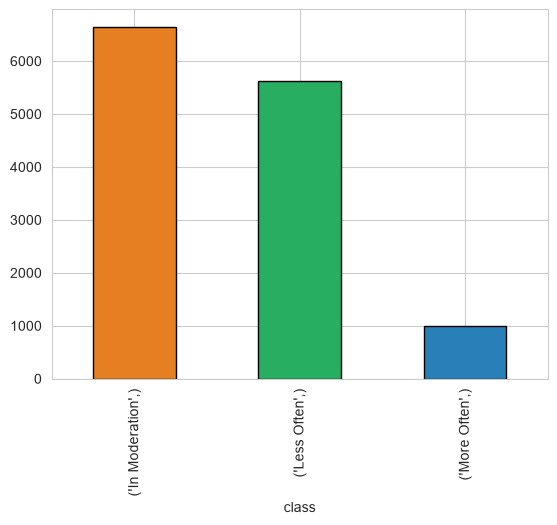

In [10]:
sns.set_style('whitegrid')
food_df.iloc[:, -1:].value_counts(normalize=True)
food_df.iloc[:, -1:].value_counts().plot.bar(color=['#e67e22', '#27ae60', '#2980b9'],
edgecolor='black')

## Data Preprocessing

In [15]:
X_raw = food_df.drop('class', axis=1)
y_raw = food_df['class']

scaler = MinMaxScaler()
encoder = LabelEncoder()

X = scaler.fit_transform(X_raw)
y = encoder.fit_transform(y_raw.values.ravel())

xtrain, xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(xtrain.shape, ytrain.shape)
print(xtest.shape, ytest.shape)

(10608, 17) (10608,)
(2652, 17) (2652,)


## Train a Neural Network with SGD (Stochastic Gradient Descent)

In [16]:
def fit_and_score(model, X_train, X_test, y_train, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start
    n_iter = model.n_iter_
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    loss_curve = model.loss_curve_
    return round(fit_time, 2), n_iter, train_score, test_score

In [19]:
mlp = MLPClassifier(
    random_state=42, 
    hidden_layer_sizes=(32, 8),
    solver='sgd', 
    momentum=0, 
    early_stopping=True,
    max_iter=100)

fit_time, iterations, train_score, test_score = fit_and_score(mlp, xtrain, xtest, ytrain, ytest)

In [20]:
print(f"Training converged after {iterations} iterations with train score (accuracy) {round(train_score, 2)} \
and test score (accuracy) {round(test_score, 2)}.")

Training converged after 12 iterations with train score (accuracy) 0.42 and test score (accuracy) 0.42.


## Using a Logistic Regression

In [22]:
lr_model = LogisticRegression(random_state=42, max_iter = 200)
lr_model.fit(xtrain, ytrain)
lr_score = lr_model.score(xtest, ytest)
print(f"The test score for the logistic regression is {round(lr_score, 2)}")

The test score for the logistic regression is 0.78


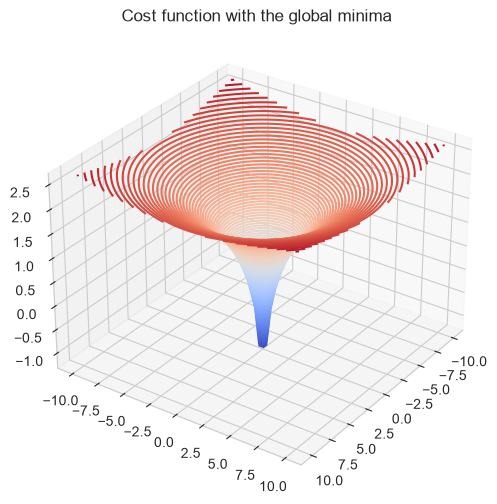

In [24]:
def draw_cost(X, Y, Z, title):
    fig = plt.figure()
    fig.set_size_inches(8, 6, forward=True)
    fig.set_dpi(100)
    ax = plt.axes(projection='3d')
    ax.view_init(30, 35)
    ax.contour3D(X, Y, Z, 100, cmap=plt.cm.coolwarm)
    ax.set_title(title)

def one_mini_function():
    w1 = np.linspace(-10, 10, 50)
    w2 = np.linspace(-10, 10, 50)
    X, Y = np.meshgrid(w1, w2)
    Z = np.log(np.sqrt(X ** 2 + Y ** 2))
    return X, Y, Z

X, Y, Z = one_mini_function()
draw_cost(X, Y, Z, "Cost function with the global minima")

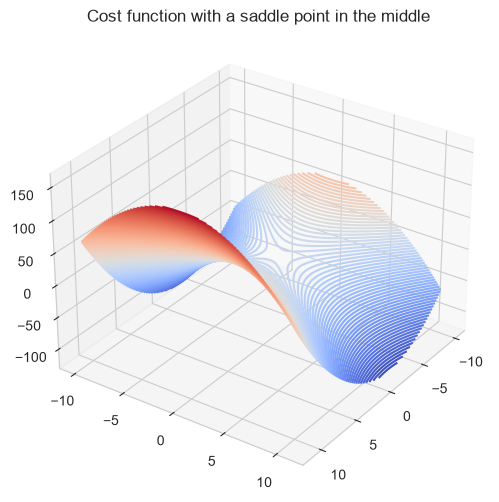

In [25]:
def multi_mini_function():
    w1 = np.linspace(-10, 11, 50)
    w2 = np.linspace(-10, 11, 50)
    X, Y = np.meshgrid(w1, w2)
    Z = X ** 2  - Y ** 2 + 4*X
    return X, Y, Z

X1, Y1, Z1 = multi_mini_function()
draw_cost(X1, Y1, Z1, "Cost function with a saddle point in the middle")

In [ ]:
momentum_ann = MLPClassifier(random_state=42,  hidden_layer_sizes=(32, 8), 
                    solver='sgd', momentum=0.9, 
                    early_stopping=True,
                    max_iter=100)
fit_time, n_iter, train_score, test_score = fit_and_score(momentum_ann, xtrain, xtest, ytrain, ytest)
print(f"Training converged after {n_iter} iterations with test score (accuracy) {round(test_score, 2)}")

Training converged after 85 iterations with test score (accuracy) 0.74


## Training NN with Nesterov Momentum

In [33]:
momentum_ann = MLPClassifier(random_state=42,  hidden_layer_sizes=(32, 8), 
                    solver='sgd', nesterovs_momentum=True, momentum=0.95,
                    early_stopping=True,
                    max_iter=100)
fit_time, n_iter, train_score, test_score = fit_and_score(momentum_ann, xtrain, xtest, ytrain, ytest)
print(f"Training converged after {n_iter} iterations with test score (accuracy) {round(test_score, 2)}")

Training converged after 67 iterations with test score (accuracy) 0.74


## Training NN with Adam Optimizer

In [34]:
momentum_ann = MLPClassifier(random_state=42,  hidden_layer_sizes=(32, 8), 
                    solver='adam', nesterovs_momentum=True, momentum=0.95,
                    early_stopping=True,
                    max_iter=100)
fit_time, n_iter, train_score, test_score = fit_and_score(momentum_ann, xtrain, xtest, ytrain, ytest)
print(f"Training converged after {n_iter} iterations with test score (accuracy) {round(test_score, 2)}")

Training converged after 100 iterations with test score (accuracy) 0.85


c:\Users\LEI\Documents\deep-learning-ibm\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


## Exercise: Comparing Optimization Methods on Fashion MNIST

In [36]:
OPTIMIZERS = ['SGD', 'SGD_momentum', 'Adam']

(xtrain, ytrain), (xtest, ytest) = fashion_mnist.load_data()

xtrain = xtrain.reshape(len(xtrain), -1)
xtest = xtest.reshape(len(xtest), -1)

xtrain = xtrain / 255.0
xtest = xtest / 255.0

ytrain = to_categorical(ytrain)
ytest = to_categorical(ytest)

split_index = 55000
xval, yval = xtrain[split_index:], ytrain[split_index:]
xtrain, ytrain = xtrain[:split_index], ytrain[:split_index]

print(xtrain.shape, xval.shape, xtest.shape)

(55000, 784) (5000, 784) (10000, 784)


In [39]:
model = Sequential([
    Dense(128, input_shape=xtrain.shape[1:], name='dense_1', activation='relu'),
    Dense(64, activation='relu', name='dense_2'), Dropout(0.2),
    Dense(10, activation='softmax', name='dense_3')
], name='Sequential')

model.summary()

Model: "Sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
from tqdm.notebook import tqdm

epochs = 10
batch_size = 64
shuffle = True

loss = {opt: [] for opt in OPTIMIZERS}
val_loss = {opt: [] for opt in OPTIMIZERS}
acc = {opt: [] for opt in OPTIMIZERS}
val_acc = {opt: [] for opt in OPTIMIZERS}
test_acc = {}
test_loss = {}

In [48]:
weights = model.get_weights().copy()

with tqdm(desc='Training', total=len(OPTIMIZERS*epochs)) as pbar:
    for name in OPTIMIZERS:
        optimizer=''
        
        # prepare model
        model.set_weights(weights)
        if name == 'SGD':
            optimizer=SGD(learning_rate=0.001)
        elif name=='SGD_momentum':
            optimizer=SGD(learning_rate=0.001, momentum=0.9)
        elif name=='Adam':
            optimizer=Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
        print('Optimizer: ', name)
        model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['acc'])
        
        # train model
        for epoch in range(epochs):
            his = model.fit(xtrain, ytrain,
                            epochs=1,
                            batch_size=batch_size,
                            validation_data=(xval, yval),
                            shuffle=shuffle,
                            verbose=0)
            
            # update dictionaries
            loss[name].append(his.history['loss'][0])
            val_loss[name].append(his.history['val_loss'][0])
            acc[name].append(his.history['acc'][0])
            val_acc[name].append(his.history['val_acc'][0])   
            pbar.update(1)
            
        # inference
        t_loss, t_acc = model.evaluate(xtest, ytest, verbose=0)
        test_loss[name] = t_loss
        test_acc[name] = t_acc

Training:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizer:  SGD
Optimizer:  SGD_momentum
Optimizer:  Adam


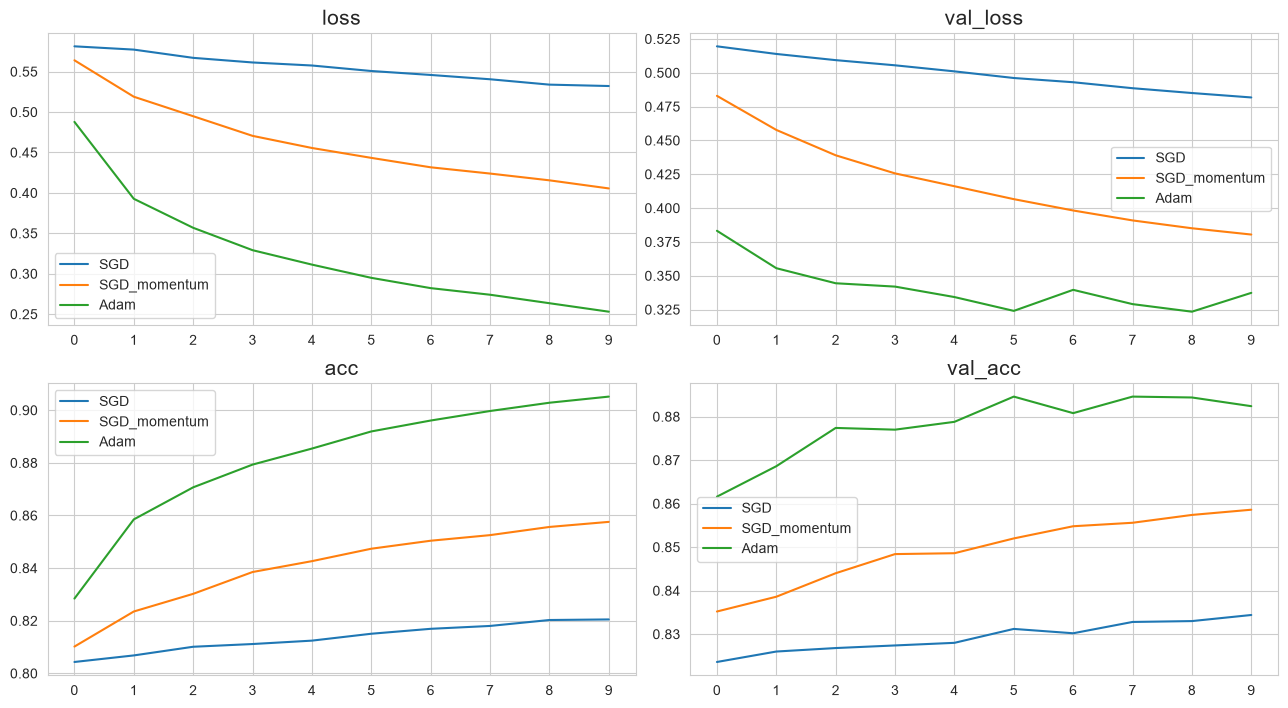

In [49]:
fig, axs = plt.subplots(2, 2, figsize=(13, 7))
plt.tight_layout()
plt.subplots_adjust(hspace=0.2)


for index, result, title in zip([[0, 0], [0, 1], [1, 0], [1, 1]], 
                                [loss, val_loss, acc, val_acc], 
                                ['loss', 'val_loss', 'acc', 'val_acc']):
    i, j = index
    for name, values in result.items():
        axs[i, j].plot(values, label=name)
        axs[i, j].set_title(title, size=15)
        axs[i, j].set_xticks([e for e in range(epochs)])
        axs[i, j].legend(loc="best", prop={'size': 10})

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


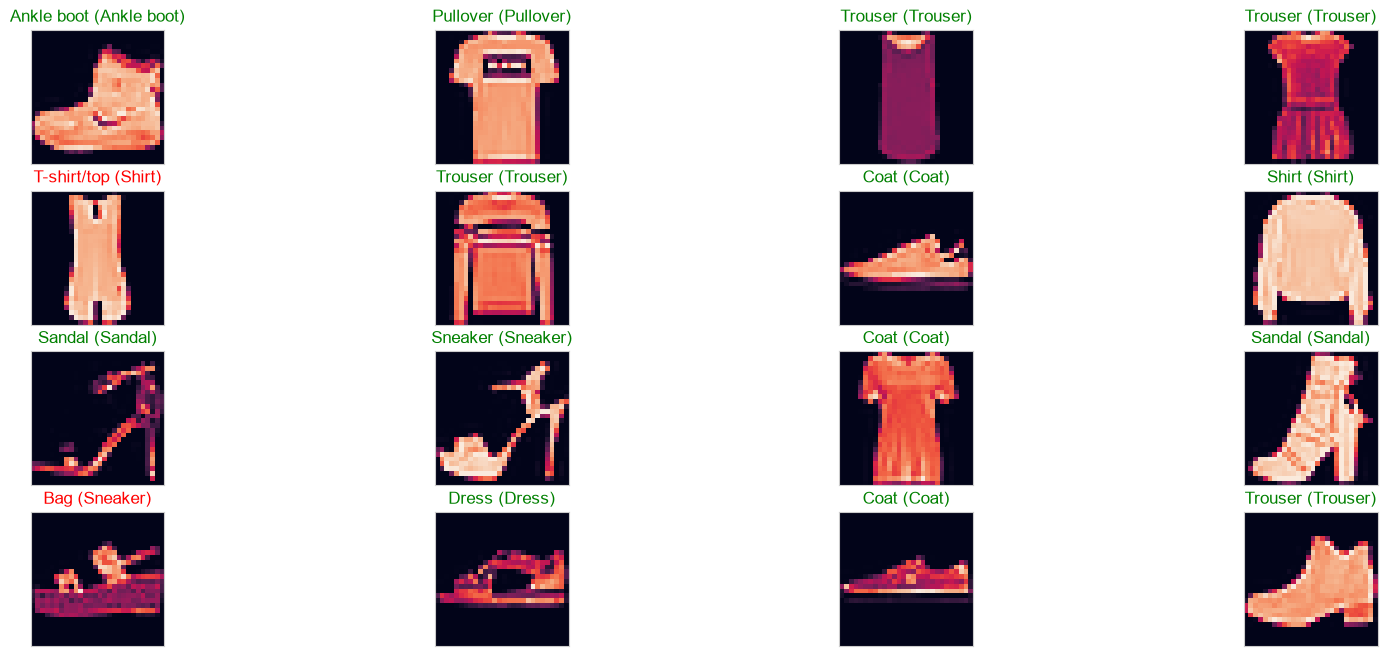

In [50]:
w, h = 28, 28
fashion_mnist_labels = ["T-shirt/top",  # index 0
                        "Trouser",      # index 1
                        "Pullover",     # index 2 
                        "Dress",        # index 3 
                        "Coat",         # index 4
                        "Sandal",       # index 5
                        "Shirt",        # index 6 
                        "Sneaker",      # index 7 
                        "Bag",          # index 8 
                        "Ankle boot"]   # index 9

y_hat = model.predict(xtest)

figure = plt.figure(figsize=(20, 8))
for i, index in enumerate(range(16)):
    
    ax = figure.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(xtrain.reshape(xtrain.shape[0], w, h, 1)[index]))
    predict_index = np.argmax(y_hat[index])
    true_index = np.argmax(ytest[index])
    ax.set_title("{} ({})".format(fashion_mnist_labels[predict_index],
                                  fashion_mnist_labels[true_index]),
                                  color=("green" if predict_index == true_index else "red"))
    